### Quantitative and Qualitative Evaluation on Static Background Videos
This notebook reproduces the experimental results for the static background grayscale video sequence presented in Section 5.3.1 of the paper. It loads the pre-computed tensor states, reconstructs the videos, and computes the seven mathematical and perceptual metrics (RE, M-RMSE, PSNR, SSIM, MS-SSIM, LPIPS, VMAF) shown in Table 2, 3.

In [ ]:
# ---------------------------------------------------------
# Environment Setup and Deep Learning Metric Initialization
# ---------------------------------------------------------
using LinearAlgebra
using Plots
using ImageQualityIndexes
using Images
using ImageIO
using FileIO
using FFMPEG_jll
using Printf
using Statistics
using Revise
using JLD2
using PyCall

In [ ]:
# Include custom modules containing the proposed Online TT-ALS, baseline algorithms, and metric functions
includet("../julia_source/myGenerateData.jl")
includet("../julia_source/myLoadVideo.jl")
includet("../julia_source/myTTD.jl")
includet("../julia_source/myIndicator.jl")

In [26]:
r = 10;

@load "data_gray_$(r).jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est

save_gray_video(video_tensor_est, "Online TT-ALS", [r, r], "results/gray", "office_onlineALS_est_$(r).mp4")
save_gray_video(video_tensor_FOA_est, "TT-FOA", [r, r], "results/gray", "office_FOA_est_$(r).mp4")
save_gray_video(video_tensor_batch_est_full, "TT-ALS", [r, r], "results/gray", "office_batchALS_est_full_$(r).mp4")
save_gray_video(video_tensor_batchSlice_est, "TT-ALS (Slice)", [r, r], "results/gray", "office_batchSliceALS_est_$(r).mp4")

[ Info: Saved animation to /home/takeda/12/results/gray/office_onlineALS_est_10.mp4
[ Info: Saved animation to /home/takeda/12/results/gray/office_FOA_est_10.mp4
[ Info: Saved animation to /home/takeda/12/results/gray/office_batchALS_est_full_10.mp4
[ Info: Saved animation to /home/takeda/12/results/gray/office_batchSliceALS_est_10.mp4


In [27]:
r = 30;

@load "data_gray_$(r).jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est

save_gray_video(video_tensor_est, "Online TT-ALS", [r, r], "results/gray", "office_onlineALS_est_$(r).mp4")
save_gray_video(video_tensor_FOA_est, "TT-FOA", [r, r], "results/gray", "office_FOA_est_$(r).mp4")
save_gray_video(video_tensor_batch_est_full, "TT-ALS", [r, r], "results/gray", "office_batchALS_est_full_$(r).mp4")
save_gray_video(video_tensor_batchSlice_est, "TT-ALS (Slice)", [r, r], "results/gray", "office_batchSliceALS_est_$(r).mp4")

[ Info: Saved animation to /home/takeda/12/results/gray/office_onlineALS_est_30.mp4
[ Info: Saved animation to /home/takeda/12/results/gray/office_FOA_est_30.mp4
[ Info: Saved animation to /home/takeda/12/results/gray/office_batchALS_est_full_30.mp4
[ Info: Saved animation to /home/takeda/12/results/gray/office_batchSliceALS_est_30.mp4


In [28]:
video_tensor, h, w, T = load_gray_video("../CDNet/office/input")
T = 500;
video_tensor = video_tensor[:, :, 351:350+T];
save_gray_video(video_tensor, "Original", [0], "results/gray", "office_original.mp4")

[ Info: Saved animation to /home/takeda/12/results/gray/office_original.mp4


In [ ]:
# Initialize the LPIPS perceptual loss model (AlexNet backbone is standard and highly efficient)
# This neural network-based metric is crucial for evaluating the perceptual fidelity of the reconstructed videos
const lpips = pyimport("lpips")
const torch = pyimport("torch")
const loss_fn = lpips.LPIPS(net="alex")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/takeda/.local/lib/python3.9/site-packages/lpips/weights/v0.1/alex.pth


/home/takeda/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/takeda/.local/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
@load "data_gray_10.jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est iter_time iter_time_FOA iter_time_batch iter_time_batchSlice

8-element Vector{Symbol}:
 :video_tensor_est
 :video_tensor_FOA_est
 :video_tensor_batch_est_full
 :video_tensor_batchSlice_est
 :iter_time
 :iter_time_FOA
 :iter_time_batch
 :iter_time_batchSlice

### Dataset Preparation & Loading

Due to file size limits and licensing, the original video datasets are not included in this repository. 
To reproduce our experiments, please download the "office" sequence from the [CDnet 2014 benchmark](http://www.changedetection.net/) and place the extracted frame images in the `../CDNet/office/input/` directory.

**Note for custom video sequences:**
If you wish to evaluate the algorithms on your own custom video data, simply prepare a folder containing the sequential frame images (e.g., `in000001.jpg`, `in000002.jpg`, ...) and update the folder path in the `load_gray_video("path/to/your/custom/video")` function below.

In [5]:
video_tensor, h, w, T = load_gray_video("../CDNet/office/input")
T = 500;
video_tensor = video_tensor[:, :, 351:350+T];
ttsizes = [h, w, T];
ttranks = [10, 10];

@show ttsizes;

ttsizes = [240, 360, 500]


In [6]:
@show size(video_tensor_est);

size(video_tensor_est) = (240, 360, 500)


In [7]:
save_gray_frame(video_tensor, "fig/gray", "office_original_frame350.pdf", 350)
save_gray_frame(video_tensor_est, "fig/gray", "office_onlineALS_est_10_frame350.pdf", 350)
save_gray_frame(video_tensor_FOA_est, "fig/gray", "office_FOA_est_10_frame350.pdf", 350)
save_gray_frame(video_tensor_batch_est_full, "fig/gray", "office_batchALS_est_full_10_frame350.pdf", 350)
save_gray_frame(video_tensor_batchSlice_est, "fig/gray", "office_batchSliceALS_est_10_frame350.pdf", 350)

"/home/takeda/12/fig/gray/office_batchSliceALS_est_10_frame350.pdf"

In [8]:
true_norm = norm(video_tensor)

nonmasked_rmse_true = norm(video_tensor - video_tensor) / true_norm
nonmasked_rmse_batch = norm(video_tensor_batch_est_full - video_tensor) / true_norm
nonmasked_rmse_batchSlice = norm(video_tensor_batchSlice_est - video_tensor) / true_norm
nonmasked_rmse_foa = norm(video_tensor_FOA_est - video_tensor) / true_norm
nonmasked_rmse_ours = norm(video_tensor_est - video_tensor) / true_norm

@printf("Non-masked RMSE True: %.6f\n", nonmasked_rmse_true);
@printf("Non-masked RMSE Batch: %.6f\n", nonmasked_rmse_batch);
@printf("Non-masked RMSE Batch Slice: %.6f\n", nonmasked_rmse_batchSlice);
@printf("Non-masked RMSE FOA: %.6f\n", nonmasked_rmse_foa);
@printf("Non-masked RMSE Ours: %.6f\n", nonmasked_rmse_ours);

Non-masked RMSE True: 0.000000
Non-masked RMSE Batch: 0.193201
Non-masked RMSE Batch Slice: 0.205007
Non-masked RMSE FOA: 0.206054
Non-masked RMSE Ours: 0.128291


In [9]:
masked_rmse_true = calc_masked_rmse_gray(video_tensor, video_tensor; threshold=0.1)
masked_rmse_batch = calc_masked_rmse_gray(video_tensor, video_tensor_batch_est_full; threshold=0.1)
masked_rmse_batchSlice = calc_masked_rmse_gray(video_tensor, video_tensor_batchSlice_est; threshold=0.1)
masked_rmse_foa = calc_masked_rmse_gray(video_tensor, video_tensor_FOA_est; threshold=0.1)
masked_rmse_ours = calc_masked_rmse_gray(video_tensor, video_tensor_est; threshold=0.1)
@printf("Masked RMSE True: %.6f\n", masked_rmse_true);
@printf("Masked RMSE Batch: %.6f\n", masked_rmse_batch);
@printf("Masked RMSE Batch Slice: %.6f\n", masked_rmse_batchSlice);
@printf("Masked RMSE FOA: %.6f\n", masked_rmse_foa);
@printf("Masked RMSE Ours: %.6f\n", masked_rmse_ours);

Masked RMSE True: 0.000000
Masked RMSE Batch: 0.184461
Masked RMSE Batch Slice: 0.160786
Masked RMSE FOA: 0.141131
Masked RMSE Ours: 0.120901


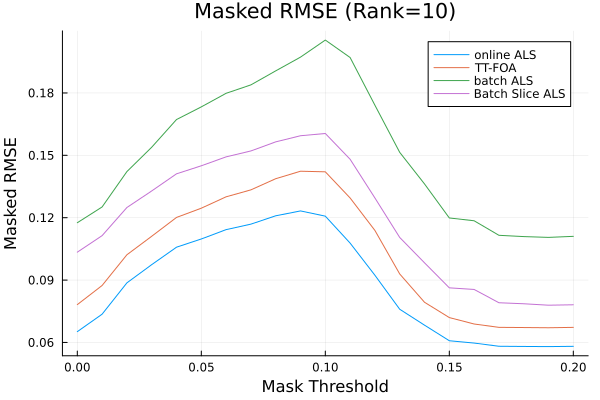

In [17]:
thresholds = 0.0:0.01:0.2
rmse_onlineALS = []
rmse_onlineFOA = []
rmse_batchALS = []
rmse_batchSliceALS = []

for th in thresholds
    push!(rmse_onlineALS, calc_masked_rmse_gray(video_tensor, video_tensor_est; threshold=th))
    push!(rmse_onlineFOA,  calc_masked_rmse_gray(video_tensor, video_tensor_FOA_est; threshold=th))
    push!(rmse_batchALS,  calc_masked_rmse_gray(video_tensor, video_tensor_batch_est_full; threshold=th))
    push!(rmse_batchSliceALS,  calc_masked_rmse_gray(video_tensor, video_tensor_batchSlice_est; threshold=th))
end

p = plot(thresholds, [rmse_onlineALS, rmse_onlineFOA, rmse_batchALS, rmse_batchSliceALS], label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], 
     xlabel="Mask Threshold", ylabel="Masked RMSE", title="Masked RMSE (Rank=10)")
savefig(p, "fig/gray/masked_rmse_10.pdf")
display(p)

Average SSIM True: 1.000000
Average SSIM Batch: 0.549274
Average SSIM Batch Slice: 0.533861
Average SSIM FOA: 0.739940
Average SSIM Ours: 0.765864


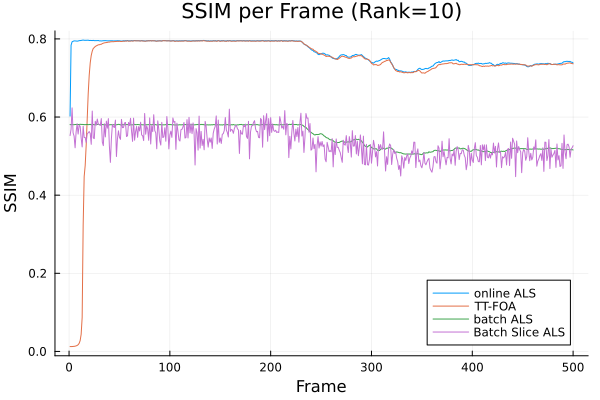

In [10]:
avg_ssim_true, ssim_list_true = calc_video_ssim_gray(video_tensor, video_tensor);
avg_ssim_batch, ssim_list_batch = calc_video_ssim_gray(video_tensor, video_tensor_batch_est_full);
avg_ssim_batchSlice, ssim_list_batchSlice = calc_video_ssim_gray(video_tensor, video_tensor_batchSlice_est);
avg_ssim_foa, ssim_list_foa = calc_video_ssim_gray(video_tensor, video_tensor_FOA_est);
avg_ssim_ours, ssim_list_ours = calc_video_ssim_gray(video_tensor, video_tensor_est);

@printf("Average SSIM True: %.6f\n", avg_ssim_true);
@printf("Average SSIM Batch: %.6f\n", avg_ssim_batch);
@printf("Average SSIM Batch Slice: %.6f\n", avg_ssim_batchSlice);
@printf("Average SSIM FOA: %.6f\n", avg_ssim_foa);
@printf("Average SSIM Ours: %.6f\n", avg_ssim_ours);

p = plot([ssim_list_ours, ssim_list_foa, ssim_list_batch, ssim_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="SSIM", title="SSIM per Frame (Rank=10)")
savefig(p, "fig/gray/ssim_per_frame_10.pdf")
display(p)

Average MS-SSIM True: 1.000078
Average MS-SSIM Batch: 0.749384
Average MS-SSIM Batch Slice: 0.754732
Average MS-SSIM FOA: 0.874512
Average MS-SSIM Ours: 0.901941


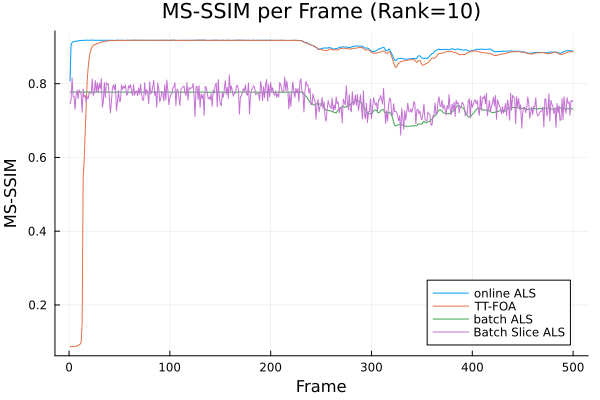

In [11]:
avg_msssim_true, msssim_list_true = calc_video_msssim_gray(video_tensor, video_tensor);
avg_msssim_batch, msssim_list_batch = calc_video_msssim_gray(video_tensor, video_tensor_batch_est_full);
avg_msssim_batchSlice, msssim_list_batchSlice = calc_video_msssim_gray(video_tensor, video_tensor_batchSlice_est);
avg_msssim_foa, msssim_list_foa = calc_video_msssim_gray(video_tensor, video_tensor_FOA_est);
avg_msssim_ours, msssim_list_ours = calc_video_msssim_gray(video_tensor, video_tensor_est);

@printf("Average MS-SSIM True: %.6f\n", avg_msssim_true);
@printf("Average MS-SSIM Batch: %.6f\n", avg_msssim_batch);
@printf("Average MS-SSIM Batch Slice: %.6f\n", avg_msssim_batchSlice);
@printf("Average MS-SSIM FOA: %.6f\n", avg_msssim_foa);
@printf("Average MS-SSIM Ours: %.6f\n", avg_msssim_ours);

p = plot([msssim_list_ours, msssim_list_foa, msssim_list_batch, msssim_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="MS-SSIM", title="MS-SSIM per Frame (Rank=10)")
savefig(p, "fig/gray/ms-ssim_per_frame_10.pdf")
display(p)

Average PSNR True: Inf
Average PSNR Batch: 20.495152
Average PSNR Batch Slice: 20.044818
Average PSNR FOA: 23.304135
Average PSNR Ours: 24.020341


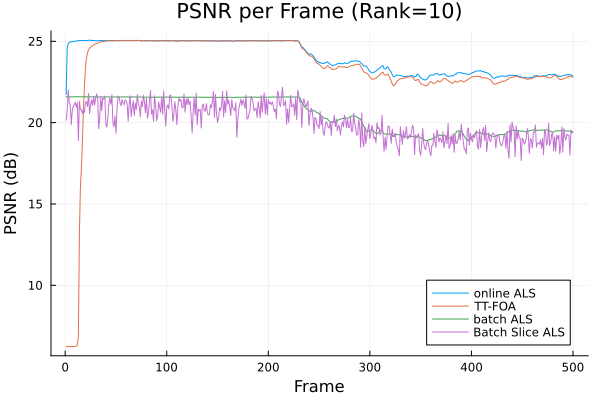

In [12]:
avg_psnr_true, psnr_list_true = calc_video_psnr_gray(video_tensor, video_tensor);
avg_psnr_batch, psnr_list_batch = calc_video_psnr_gray(video_tensor, video_tensor_batch_est_full);
avg_psnr_batchSlice, psnr_list_batchSlice = calc_video_psnr_gray(video_tensor, video_tensor_batchSlice_est);
avg_psnr_foa, psnr_list_foa = calc_video_psnr_gray(video_tensor, video_tensor_FOA_est);
avg_psnr_ours, psnr_list_ours = calc_video_psnr_gray(video_tensor, video_tensor_est);

@printf("Average PSNR True: %.6f\n", avg_psnr_true);
@printf("Average PSNR Batch: %.6f\n", avg_psnr_batch);
@printf("Average PSNR Batch Slice: %.6f\n", avg_psnr_batchSlice);
@printf("Average PSNR FOA: %.6f\n", avg_psnr_foa);
@printf("Average PSNR Ours: %.6f\n", avg_psnr_ours);

p = plot([psnr_list_ours, psnr_list_foa, psnr_list_batch, psnr_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="PSNR (dB)", title="PSNR per Frame (Rank=10)")
savefig(p, "fig/gray/psnr_per_frame_10.pdf")
display(p)

Average LPIPS True: 0.000000
Average LPIPS Batch: 0.540899
Average LPIPS Batch Slice: 0.522995
Average LPIPS FOA: 0.369263
Average LPIPS Ours: 0.346031


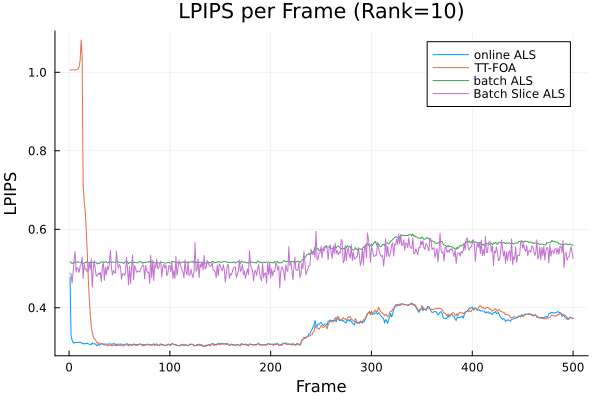

In [13]:
avg_lpips_true, lpips_list_true = calc_video_lpips_gray(video_tensor, video_tensor);
avg_lpips_batch, lpips_list_batch = calc_video_lpips_gray(video_tensor, video_tensor_batch_est_full);
avg_lpips_batchSlice, lpips_list_batchSlice = calc_video_lpips_gray(video_tensor, video_tensor_batchSlice_est);
avg_lpips_foa, lpips_list_foa = calc_video_lpips_gray(video_tensor, video_tensor_FOA_est);
avg_lpips_ours, lpips_list_ours = calc_video_lpips_gray(video_tensor, video_tensor_est);

@printf("Average LPIPS True: %.6f\n", avg_lpips_true);
@printf("Average LPIPS Batch: %.6f\n", avg_lpips_batch);
@printf("Average LPIPS Batch Slice: %.6f\n", avg_lpips_batchSlice);
@printf("Average LPIPS FOA: %.6f\n", avg_lpips_foa);
@printf("Average LPIPS Ours: %.6f\n", avg_lpips_ours);

p = plot([lpips_list_ours, lpips_list_foa, lpips_list_batch, lpips_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="LPIPS", title="LPIPS per Frame (Rank=10)")
savefig(p, "fig/gray/lpips_per_frame_10.pdf")
display(p)

In [14]:
vmaf_true = calc_video_vmaf_gray(video_tensor, video_tensor);
vmaf_batch = calc_video_vmaf_gray(video_tensor, video_tensor_batch_est_full);
vmaf_batchSlice = calc_video_vmaf_gray(video_tensor, video_tensor_batchSlice_est);
vmaf_foa = calc_video_vmaf_gray(video_tensor, video_tensor_FOA_est);
vmaf_ours = calc_video_vmaf_gray(video_tensor, video_tensor_est);
@printf("VMAF True: %.6f\n", vmaf_true);
@printf("VMAF Batch: %.6f\n", vmaf_batch);
@printf("VMAF Batch Slice: %.6f\n", vmaf_batchSlice);
@printf("VMAF FOA: %.6f\n", vmaf_foa);
@printf("VMAF Ours: %.6f\n", vmaf_ours);

VMAF True: 98.863214
VMAF Batch: 19.679545
VMAF Batch Slice: 21.196553
VMAF FOA: 39.847742
VMAF Ours: 42.348939


In [ ]:
"""
Helper function to format evaluation metrics for LaTeX tables.
It automatically highlights the best value in bold and the second-best value with an underline.

Inputs:
- val: The specific metric value to be formatted.
- all_vals: Array of all values in the same column for ranking comparison.
- high_is_better: Boolean indicating whether a higher value represents better performance.
- fmt: String format for the floating-point numeric value.

Returns:
- A formatted LaTeX string (e.g., "\\textbf{0.123}", "\\underline{0.125}", or "0.130").
"""
function fmt_rank(val, all_vals; high_is_better=true, fmt="%.3f")
    # Sort the values to determine the rankings 
    # (Descending if higher is better, Ascending if lower is better)
    sorted = sort(all_vals, rev=high_is_better)
    
    # Format the numeric value as a string
    val_str = Printf.format(Printf.Format(fmt), val)
    
    # Apply LaTeX formatting based on the rank
    if val == sorted[1]
        return "\\textbf{$val_str}"      # 1st place: Bold
    elseif val == sorted[2]
        return "\\underline{$val_str}"   # 2nd place: Underline
    else
        return val_str                   # Others: Plain text
    end
end

# ---------------------------------------------------------
# Data Aggregation
# ---------------------------------------------------------
# Aggregate the calculated metrics into arrays corresponding to each algorithm.
# The expected order is: [TT-ALS, TT-ALS (Slice), TT-FOA, Online TT-ALS (Ours)]

re_all      = [nonmasked_rmse_batch, nonmasked_rmse_batchSlice, nonmasked_rmse_foa, nonmasked_rmse_ours]
m_rmse_all  = [masked_rmse_batch, masked_rmse_batchSlice, masked_rmse_foa, masked_rmse_ours]
psnr_all    = [avg_psnr_batch, avg_psnr_batchSlice, avg_psnr_foa, avg_psnr_ours]
ssim_all    = [avg_ssim_batch, avg_ssim_batchSlice, avg_ssim_foa, avg_ssim_ours]
ms_ssim_all = [avg_msssim_batch, avg_msssim_batchSlice, avg_msssim_foa, avg_msssim_ours]
lpips_all   = [avg_lpips_batch, avg_lpips_batchSlice, avg_lpips_foa, avg_lpips_ours]
vmaf_all    = [vmaf_batch, vmaf_batchSlice, vmaf_foa, vmaf_ours]
mean_time_all = [mean(iter_time_batch), mean(iter_time_batchSlice), mean(iter_time_FOA), mean(iter_time)]

method_names = [
    "TT-ALS              ",
    "TT-ALS (Slice)      ",
    "TT-FOA              ",
    "Online TT-ALS (Ours)"
]

# ---------------------------------------------------------
# LaTeX Table Generation
# ---------------------------------------------------------
# Automatically generate the LaTeX code for the quantitative evaluation table.
# This output can be directly copied and pasted into the paper's .tex file.

println(raw"\begin{table}[t]")
println(raw"\centering")
println(raw"\caption{Quantitative comparison of algorithms on the grayscale video ($r=(10,10)$).}")
println(raw"\label{tab:comparison_gray_10}")
println(raw"\resizebox{\columnwidth}{!}{")
println(raw"\begin{tabular}{l cc c cc c cc c}")
println(raw"\toprule")
println(raw"& \multicolumn{3}{c}{\textbf{Mathematical}} & \multicolumn{2}{c}{\textbf{Structural}} & \multicolumn{2}{c}{\textbf{Perceptual}} & \textbf{Time} \\")
println(raw"\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}")
println(raw"\textbf{Method} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\") 
println(raw"\midrule")

# Iterate through the algorithms and format each row
for i in 1:length(method_names)
    @printf("%s & %s & %s & %s & %s & %s & %s & %s & %s \\\\\n",
        method_names[i],
        # RE (Lower is better: high_is_better=false)
        fmt_rank(re_all[i], re_all, high_is_better=false, fmt="%.3f"),
        # M-RMSE (Lower is better: high_is_better=false)
        fmt_rank(m_rmse_all[i], m_rmse_all, high_is_better=false, fmt="%.3f"),
        # PSNR (Higher is better: high_is_better=true)
        fmt_rank(psnr_all[i], psnr_all, high_is_better=true, fmt="%.2f"),
        # SSIM (Higher is better: high_is_better=true)
        fmt_rank(ssim_all[i], ssim_all, high_is_better=true, fmt="%.3f"),
        # MS-SSIM (Higher is better: high_is_better=true)
        fmt_rank(ms_ssim_all[i], ms_ssim_all, high_is_better=true, fmt="%.3f"),
        # LPIPS (Lower is better: high_is_better=false)
        fmt_rank(lpips_all[i], lpips_all, high_is_better=false, fmt="%.3f"),
        # VMAF (Higher is better: high_is_better=true)
        fmt_rank(vmaf_all[i], vmaf_all, high_is_better=true, fmt="%.2f"),
        # Mean Time (Lower is better: high_is_better=false)
        fmt_rank(mean_time_all[i], mean_time_all, high_is_better=false, fmt="%.3f")
    )
end

println(raw"\bottomrule")
println(raw"\end{tabular}")
println(raw"}")
println(raw"\end{table}")

\begin{table}[t]
\centering
\caption{グレースケール動画における各アルゴリズムの定量評価結果の比較（$r=(10,10)$）．}
\label{tab:comparison_gray_10}
\resizebox{\columnwidth}{!}{
\begin{tabular}{l cc c cc c cc c}
\toprule
& \multicolumn{3}{c}{\textbf{数理的指標}} & \multicolumn{2}{c}{\textbf{構造的指標}} & \multicolumn{2}{c}{\textbf{知覚・動画品質指標}} & \textbf{実行時間} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
\textbf{手法} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\
\midrule
TT-ALS                & \underline{0.193} & 0.184 & 20.50 & 0.549 & 0.749 & 0.541 & 19.68 & 2138.088 \\
TT-ALS (Slice)        & 0.205 & 0.161 & 20.04 & 0.534 & 0.755 & 0.523 & 21.20 & \textbf{2.244} \\
TT-FOA                & 0.206 & \underline{0.141} & \underline{23.30} & \underline{0.740} & \underline{0.875} & \underline{0.369} & \underline{39.85} & 5.370 \\
Online TT-ALS（提案手法） & \textbf{0.128} 

# Gray (rank = (30, 30))

In [16]:
@load "data_gray_30.jld2" video_tensor_est video_tensor_FOA_est video_tensor_batch_est_full video_tensor_batchSlice_est iter_time iter_time_FOA iter_time_batch iter_time_batchSlice

8-element Vector{Symbol}:
 :video_tensor_est
 :video_tensor_FOA_est
 :video_tensor_batch_est_full
 :video_tensor_batchSlice_est
 :iter_time
 :iter_time_FOA
 :iter_time_batch
 :iter_time_batchSlice

In [17]:
save_gray_frame(video_tensor, "fig/gray", "office_original_frame350.pdf", 350)
save_gray_frame(video_tensor_est, "fig/gray", "office_onlineALS_est_30_frame350.pdf", 350)
save_gray_frame(video_tensor_FOA_est, "fig/gray", "office_FOA_est_30_frame350.pdf", 350)
save_gray_frame(video_tensor_batch_est_full, "fig/gray", "office_batchALS_est_full_30_frame350.pdf", 350)
save_gray_frame(video_tensor_batchSlice_est, "fig/gray", "office_batchSliceALS_est_30_frame350.pdf", 350)

"/home/takeda/12/fig/gray/office_batchSliceALS_est_30_frame350.pdf"

In [18]:
true_norm = norm(video_tensor)

nonmasked_rmse_true = norm(video_tensor - video_tensor) / true_norm
nonmasked_rmse_batch = norm(video_tensor_batch_est_full - video_tensor) / true_norm
nonmasked_rmse_batchSlice = norm(video_tensor_batchSlice_est - video_tensor) / true_norm
nonmasked_rmse_foa = norm(video_tensor_FOA_est - video_tensor) / true_norm
nonmasked_rmse_ours = norm(video_tensor_est - video_tensor) / true_norm

@printf("Non-masked RMSE True: %.6f\n", nonmasked_rmse_true);
@printf("Non-masked RMSE Batch: %.6f\n", nonmasked_rmse_batch);
@printf("Non-masked RMSE Batch Slice: %.6f\n", nonmasked_rmse_batchSlice);
@printf("Non-masked RMSE FOA: %.6f\n", nonmasked_rmse_foa);
@printf("Non-masked RMSE Ours: %.6f\n", nonmasked_rmse_ours);

Non-masked RMSE True: 0.000000
Non-masked RMSE Batch: 0.124061
Non-masked RMSE Batch Slice: 0.108498
Non-masked RMSE FOA: 0.171213
Non-masked RMSE Ours: 0.068303


In [19]:
masked_rmse_true = calc_masked_rmse_gray(video_tensor, video_tensor; threshold=0.1)
masked_rmse_batch = calc_masked_rmse_gray(video_tensor, video_tensor_batch_est_full; threshold=0.1)
masked_rmse_batchSlice = calc_masked_rmse_gray(video_tensor, video_tensor_batchSlice_est; threshold=0.1)
masked_rmse_foa = calc_masked_rmse_gray(video_tensor, video_tensor_FOA_est; threshold=0.1)
masked_rmse_ours = calc_masked_rmse_gray(video_tensor, video_tensor_est; threshold=0.1)
@printf("Masked RMSE True: %.6f\n", masked_rmse_true);
@printf("Masked RMSE Batch: %.6f\n", masked_rmse_batch);
@printf("Masked RMSE Batch Slice: %.6f\n", masked_rmse_batchSlice);
@printf("Masked RMSE FOA: %.6f\n", masked_rmse_foa);
@printf("Masked RMSE Ours: %.6f\n", masked_rmse_ours);

Masked RMSE True: 0.000000
Masked RMSE Batch: 0.120450
Masked RMSE Batch Slice: 0.089770
Masked RMSE FOA: 0.102142
Masked RMSE Ours: 0.075319


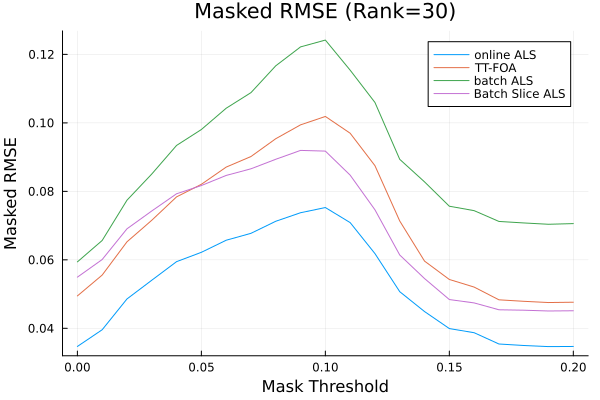

In [28]:
thresholds = 0.0:0.01:0.2
rmse_onlineALS = []
rmse_onlineFOA = []
rmse_batchALS = []
rmse_batchSliceALS = []

for th in thresholds
    push!(rmse_onlineALS, calc_masked_rmse_gray(video_tensor, video_tensor_est; threshold=th))
    push!(rmse_onlineFOA,  calc_masked_rmse_gray(video_tensor, video_tensor_FOA_est; threshold=th))
    push!(rmse_batchALS,  calc_masked_rmse_gray(video_tensor, video_tensor_batch_est_full; threshold=th))
    push!(rmse_batchSliceALS,  calc_masked_rmse_gray(video_tensor, video_tensor_batchSlice_est; threshold=th))
end

p = plot(thresholds, [rmse_onlineALS, rmse_onlineFOA, rmse_batchALS, rmse_batchSliceALS], label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], 
     xlabel="Mask Threshold", ylabel="Masked RMSE", title="Masked RMSE (Rank=30)")
savefig(p, "fig/gray/masked_rmse_30.pdf")
display(p)

Average SSIM True: 1.000000
Average SSIM Batch: 0.669208
Average SSIM Batch Slice: 0.703927
Average SSIM FOA: 0.841079
Average SSIM Ours: 0.874060


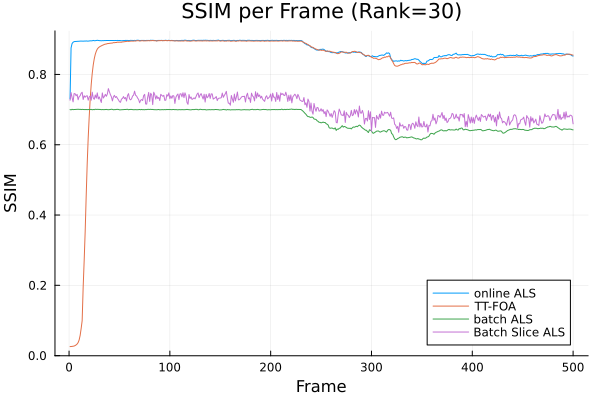

In [20]:
avg_ssim_true, ssim_list_true = calc_video_ssim_gray(video_tensor, video_tensor);
avg_ssim_batch, ssim_list_batch = calc_video_ssim_gray(video_tensor, video_tensor_batch_est_full);
avg_ssim_batchSlice, ssim_list_batchSlice = calc_video_ssim_gray(video_tensor, video_tensor_batchSlice_est);
avg_ssim_foa, ssim_list_foa = calc_video_ssim_gray(video_tensor, video_tensor_FOA_est);
avg_ssim_ours, ssim_list_ours = calc_video_ssim_gray(video_tensor, video_tensor_est);
@printf("Average SSIM True: %.6f\n", avg_ssim_true);
@printf("Average SSIM Batch: %.6f\n", avg_ssim_batch);
@printf("Average SSIM Batch Slice: %.6f\n", avg_ssim_batchSlice);
@printf("Average SSIM FOA: %.6f\n", avg_ssim_foa);
@printf("Average SSIM Ours: %.6f\n", avg_ssim_ours);

p = plot([ssim_list_ours, ssim_list_foa, ssim_list_batch, ssim_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="SSIM", title="SSIM per Frame (Rank=30)")
savefig(p, "fig/gray/ssim_per_frame_30.pdf")
display(p)

Average MS-SSIM True: 1.000078
Average MS-SSIM Batch: 0.880261
Average MS-SSIM Batch Slice: 0.906888
Average MS-SSIM FOA: 0.944010
Average MS-SSIM Ours: 0.972819


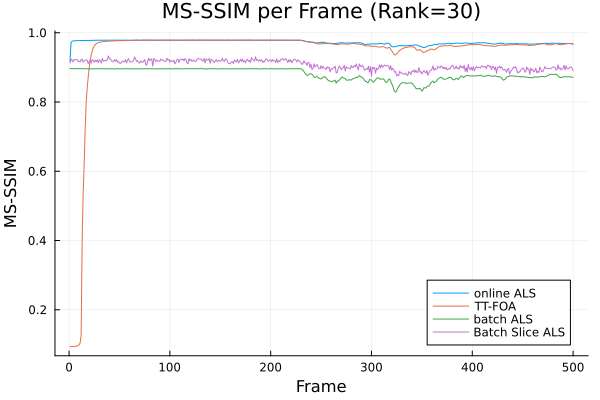

In [21]:
avg_msssim_true, msssim_list_true = calc_video_msssim_gray(video_tensor, video_tensor);
avg_msssim_batch, msssim_list_batch = calc_video_msssim_gray(video_tensor, video_tensor_batch_est_full);
avg_msssim_batchSlice, msssim_list_batchSlice = calc_video_msssim_gray(video_tensor, video_tensor_batchSlice_est);
avg_msssim_foa, msssim_list_foa = calc_video_msssim_gray(video_tensor, video_tensor_FOA_est);
avg_msssim_ours, msssim_list_ours = calc_video_msssim_gray(video_tensor, video_tensor_est);
@printf("Average MS-SSIM True: %.6f\n", avg_msssim_true);
@printf("Average MS-SSIM Batch: %.6f\n", avg_msssim_batch);
@printf("Average MS-SSIM Batch Slice: %.6f\n", avg_msssim_batchSlice);
@printf("Average MS-SSIM FOA: %.6f\n", avg_msssim_foa);
@printf("Average MS-SSIM Ours: %.6f\n", avg_msssim_ours);

p = plot([msssim_list_ours, msssim_list_foa, msssim_list_batch, msssim_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="MS-SSIM", title="MS-SSIM per Frame (Rank=30)")
savefig(p, "fig/gray/ms-ssim_per_frame_30.pdf")
display(p)

Average PSNR True: Inf
Average PSNR Batch: 24.370959
Average PSNR Batch Slice: 25.534612
Average PSNR FOA: 28.265821
Average PSNR Ours: 29.539844


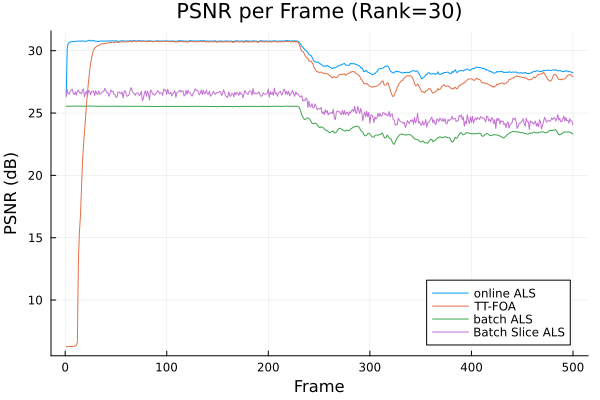

In [22]:
avg_psnr_true, psnr_list_true = calc_video_psnr_gray(video_tensor, video_tensor);
avg_psnr_batch, psnr_list_batch = calc_video_psnr_gray(video_tensor, video_tensor_batch_est_full);
avg_psnr_batchSlice, psnr_list_batchSlice = calc_video_psnr_gray(video_tensor, video_tensor_batchSlice_est);
avg_psnr_foa, psnr_list_foa = calc_video_psnr_gray(video_tensor, video_tensor_FOA_est);
avg_psnr_ours, psnr_list_ours = calc_video_psnr_gray(video_tensor, video_tensor_est);
@printf("Average PSNR True: %.6f\n", avg_psnr_true);
@printf("Average PSNR Batch: %.6f\n", avg_psnr_batch);
@printf("Average PSNR Batch Slice: %.6f\n", avg_psnr_batchSlice);
@printf("Average PSNR FOA: %.6f\n", avg_psnr_foa);
@printf("Average PSNR Ours: %.6f\n", avg_psnr_ours);

p = plot([psnr_list_ours, psnr_list_foa, psnr_list_batch, psnr_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="PSNR (dB)", title="PSNR per Frame (Rank=30)")
savefig(p, "fig/gray/psnr_per_frame_30.pdf")
display(p)

Average LPIPS True: 0.000000
Average LPIPS Batch: 0.397487
Average LPIPS Batch Slice: 0.356560
Average LPIPS FOA: 0.210758
Average LPIPS Ours: 0.172981


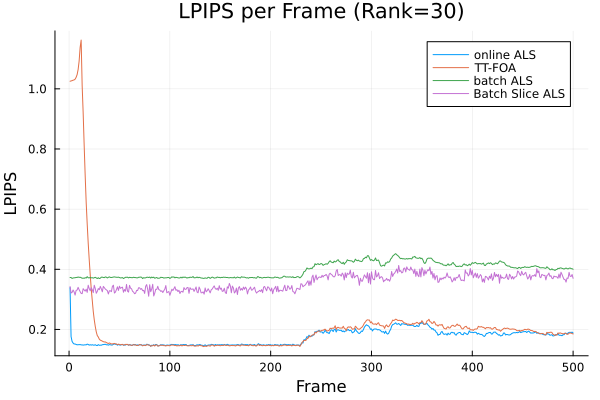

In [23]:
avg_lpips_true, lpips_list_true = calc_video_lpips_gray(video_tensor, video_tensor);
avg_lpips_batch, lpips_list_batch = calc_video_lpips_gray(video_tensor, video_tensor_batch_est_full);
avg_lpips_batchSlice, lpips_list_batchSlice = calc_video_lpips_gray(video_tensor, video_tensor_batchSlice_est);
avg_lpips_foa, lpips_list_foa = calc_video_lpips_gray(video_tensor, video_tensor_FOA_est);
avg_lpips_ours, lpips_list_ours = calc_video_lpips_gray(video_tensor, video_tensor_est);
@printf("Average LPIPS True: %.6f\n", avg_lpips_true);
@printf("Average LPIPS Batch: %.6f\n", avg_lpips_batch);
@printf("Average LPIPS Batch Slice: %.6f\n", avg_lpips_batchSlice);
@printf("Average LPIPS FOA: %.6f\n", avg_lpips_foa);
@printf("Average LPIPS Ours: %.6f\n", avg_lpips_ours);

p = plot([lpips_list_ours, lpips_list_foa, lpips_list_batch, lpips_list_batchSlice], 
     label=["online ALS" "TT-FOA" "batch ALS" "Batch Slice ALS"], xlabel="Frame", ylabel="LPIPS", title="LPIPS per Frame (Rank=30)")
savefig(p, "fig/gray/lpips_per_frame_30.pdf")
display(p)

In [24]:
vmaf_true = calc_video_vmaf_gray(video_tensor, video_tensor);
vmaf_batch = calc_video_vmaf_gray(video_tensor, video_tensor_batch_est_full);
vmaf_batchSlice = calc_video_vmaf_gray(video_tensor, video_tensor_batchSlice_est);
vmaf_foa = calc_video_vmaf_gray(video_tensor, video_tensor_FOA_est);
vmaf_ours = calc_video_vmaf_gray(video_tensor, video_tensor_est);
@printf("VMAF True: %.6f\n", vmaf_true);
@printf("VMAF Batch: %.6f\n", vmaf_batch);
@printf("VMAF Batch Slice: %.6f\n", vmaf_batchSlice);
@printf("VMAF FOA: %.6f\n", vmaf_foa);
@printf("VMAF Ours: %.6f\n", vmaf_ours);

VMAF True: 98.863214
VMAF Batch: 47.181831
VMAF Batch Slice: 53.732105
VMAF FOA: 76.756513
VMAF Ours: 82.922358


In [ ]:
# ---------------------------------------------------------
# Data Aggregation (r = 30)
# ---------------------------------------------------------
# Aggregate the calculated metrics into arrays corresponding to each algorithm.
# The expected order is: [TT-ALS, TT-ALS (Slice), TT-FOA, Online TT-ALS (Ours)]

re_all      = [nonmasked_rmse_batch, nonmasked_rmse_batchSlice, nonmasked_rmse_foa, nonmasked_rmse_ours]
m_rmse_all  = [masked_rmse_batch, masked_rmse_batchSlice, masked_rmse_foa, masked_rmse_ours]
psnr_all    = [avg_psnr_batch, avg_psnr_batchSlice, avg_psnr_foa, avg_psnr_ours]
ssim_all    = [avg_ssim_batch, avg_ssim_batchSlice, avg_ssim_foa, avg_ssim_ours]
ms_ssim_all = [avg_msssim_batch, avg_msssim_batchSlice, avg_msssim_foa, avg_msssim_ours]
lpips_all   = [avg_lpips_batch, avg_lpips_batchSlice, avg_lpips_foa, avg_lpips_ours]
vmaf_all    = [vmaf_batch, vmaf_batchSlice, vmaf_foa, vmaf_ours]
mean_time_all = [mean(iter_time_batch), mean(iter_time_batchSlice), mean(iter_time_FOA), mean(iter_time)]

method_names = [
    "TT-ALS              ",
    "TT-ALS (Slice)      ",
    "TT-FOA              ",
    "Online TT-ALS (Ours)"
]

# ---------------------------------------------------------
# LaTeX Table Generation
# ---------------------------------------------------------
# Automatically generate the LaTeX code for the quantitative evaluation table.
# This output can be directly copied and pasted into the paper's .tex file.

println(raw"\begin{table}[t]")
println(raw"\centering")
println(raw"\caption{Quantitative comparison of algorithms on the grayscale video ($r=(30,30)$).}")
println(raw"\label{tab:comparison_gray_30}")
println(raw"\resizebox{\columnwidth}{!}{")
println(raw"\begin{tabular}{l cc c cc c cc c}")
println(raw"\toprule")
println(raw"& \multicolumn{3}{c}{\textbf{Mathematical}} & \multicolumn{2}{c}{\textbf{Structural}} & \multicolumn{2}{c}{\textbf{Perceptual}} & \textbf{Time} \\")
println(raw"\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}")
println(raw"\textbf{Method} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\") 
println(raw"\midrule")

# Iterate through the algorithms and format each row
for i in 1:length(method_names)
    @printf("%s & %s & %s & %s & %s & %s & %s & %s & %s \\\\\n",
        method_names[i],
        # RE (Lower is better: high_is_better=false)
        fmt_rank(re_all[i], re_all, high_is_better=false, fmt="%.3f"),
        # M-RMSE (Lower is better: high_is_better=false)
        fmt_rank(m_rmse_all[i], m_rmse_all, high_is_better=false, fmt="%.3f"),
        # PSNR (Higher is better: high_is_better=true)
        fmt_rank(psnr_all[i], psnr_all, high_is_better=true, fmt="%.2f"),
        # SSIM (Higher is better: high_is_better=true)
        fmt_rank(ssim_all[i], ssim_all, high_is_better=true, fmt="%.3f"),
        # MS-SSIM (Higher is better: high_is_better=true)
        fmt_rank(ms_ssim_all[i], ms_ssim_all, high_is_better=true, fmt="%.3f"),
        # LPIPS (Lower is better: high_is_better=false)
        fmt_rank(lpips_all[i], lpips_all, high_is_better=false, fmt="%.3f"),
        # VMAF (Higher is better: high_is_better=true)
        fmt_rank(vmaf_all[i], vmaf_all, high_is_better=true, fmt="%.2f"),
        # Mean Time (Lower is better: high_is_better=false)
        fmt_rank(mean_time_all[i], mean_time_all, high_is_better=false, fmt="%.3f")
    )
end

println(raw"\bottomrule")
println(raw"\end{tabular}")
println(raw"}")
println(raw"\end{table}")

\begin{table}[t]
\centering
\caption{グレースケール動画における各アルゴリズムの定量評価結果の比較（$r=(30,30)$）．}
\label{tab:comparison_gray_30}
\resizebox{\columnwidth}{!}{
\begin{tabular}{l cc c cc c cc c}
\toprule
& \multicolumn{3}{c}{\textbf{数理的指標}} & \multicolumn{2}{c}{\textbf{構造的指標}} & \multicolumn{2}{c}{\textbf{知覚・動画品質指標}} & \textbf{実行時間} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-9}
\textbf{手法} & RE $\downarrow$ & M-RMSE $\downarrow$ & PSNR $\uparrow$ & SSIM $\uparrow$ & MS-SSIM $\uparrow$ & LPIPS $\downarrow$ & VMAF $\uparrow$ & \makecell{Mean Time \\ (ms) $\downarrow$} \\
\midrule
TT-ALS                & 0.124 & 0.120 & 24.37 & 0.669 & 0.880 & 0.397 & 47.18 & 2307.555 \\
TT-ALS (Slice)        & \underline{0.108} & \underline{0.090} & 25.53 & 0.704 & 0.907 & 0.357 & 53.73 & \textbf{3.963} \\
TT-FOA                & 0.171 & 0.102 & \underline{28.27} & \underline{0.841} & \underline{0.944} & \underline{0.211} & \underline{76.76} & 268.663 \\
Online TT-ALS（提案手法） & \textbf{0.068